# 1: Artificial Neural Network with Backpropagation

- Build an ANN **from scratch** (no ML libraries) with configurable hidden layer size
- Architecture: 2 input → N hidden → 1 output
- **XOR task**: binary classification with sigmoid activations + binary cross-entropy loss
- **Cosine task**: regression with tanh hidden + linear output + MSE loss
- Dataset generated by adding Gaussian noise to base inputs; split 80/20 train/test
- Report: loss & accuracy curves, final metrics
- Experiments:
  - **Deterministic GD**: vary number of training samples *n* (3 values)
  - **Stochastic GD (mini-batch)**: vary batch size *m* (3 values, fixed *n*)

In [28]:
import numpy as np
import matplotlib.pyplot as plt

In [29]:
#   Activation functions
def sigmoid(x):     return 1 / (1 + np.exp(-x))
def sigmoid_d(x):   return sigmoid(x) * (1 - sigmoid(x))
def tanh_d(x):      return 1 - np.tanh(x)**2

In [ ]:
class ANN:
    def __init__(self, n_hidden=2, task='xor', lr=0.1):
        self.task = task
        self.lr   = lr
        # weights
        self.W1 = np.random.randn(2, n_hidden) * 0.5
        self.b1 = np.zeros((1, n_hidden))
        self.W2 = np.random.randn(n_hidden, 1) * 0.5
        self.b2 = np.zeros((1, 1))

    def forward(self, X):
        self.z1 = X @ self.W1 + self.b1
        self.a1 = np.tanh(self.z1)
        self.z2 = self.a1 @ self.W2 + self.b2
        self.a2 = sigmoid(self.z2) if self.task == 'xor' else self.z2
        return self.a2

    def loss(self, y_pred, y_true):
        if self.task == 'xor':      # binary cross-entropy
            y_pred = np.clip(y_pred, 1e-9, 1 - 1e-9)
            return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
        else:                        # MSE
            return np.mean((y_pred - y_true) ** 2)

    def accuracy(self, y_pred, y_true):
        if self.task == 'xor':
            return np.mean((y_pred >= 0.5) == y_true)
        else:                        # within 10% of range
            rng = y_true.max() - y_true.min() + 1e-9
            return np.mean(np.abs(y_pred - y_true) / rng < 0.1)

    def backward(self, X, y_true):
        n = X.shape[0]
        if self.task == 'xor':
            dL_da2 = -(y_true / np.clip(self.a2, 1e-9, 1-1e-9) -
                       (1 - y_true) / np.clip(1 - self.a2, 1e-9, 1-1e-9)) / n
            dL_dz2 = dL_da2 * sigmoid_d(self.z2)
        else:
            dL_dz2 = 2 * (self.a2 - y_true) / n   # linear output

        dL_dW2 = self.a1.T @ dL_dz2
        dL_db2 = dL_dz2.sum(axis=0, keepdims=True)
        dL_da1 = dL_dz2 @ self.W2.T
        dL_dz1 = dL_da1 * tanh_d(self.z1)
        dL_dW1 = X.T @ dL_dz1
        dL_db1 = dL_dz1.sum(axis=0, keepdims=True)

        self.W2 -= self.lr * dL_dW2;  self.b2 -= self.lr * dL_db2
        self.W1 -= self.lr * dL_dW1;  self.b1 -= self.lr * dL_db1

    def train_epoch(self, X, y, batch_size=None):
        if batch_size is None or batch_size >= len(X):
            self.forward(X); self.backward(X, y)
        else:
            idx = np.random.permutation(len(X))
            for i in range(0, len(X), batch_size):
                b = idx[i:i+batch_size]
                self.forward(X[b]); self.backward(X[b], y[b])

### Dataset generation

In [31]:
def make_xor_data(n, noise=0.05):
    base = np.array([[0,0],[0,1],[1,0],[1,1]])
    labels = np.array([[0],[1],[1],[0]])
    idx = np.random.randint(0, 4, n)
    X = base[idx] + np.random.randn(n, 2) * noise
    y = labels[idx].astype(float)
    return X, y

def make_cosine_data(n, noise=0.05):
    x = np.random.uniform(0, 2*np.pi, n)        # x in [0, 2π]
    X = np.column_stack([np.sin(x), np.cos(x)]) # [sin(x), cos(x)] as inputs
    X += np.random.randn(n, 2) * noise           # Gaussian noise
    y = np.cos(x).reshape(-1, 1)                 # target: cos(x)
    return X, y

def split(X, y, ratio=0.8):
    n = int(len(X) * ratio)
    return X[:n], y[:n], X[n:], y[n:]

In [32]:
def train(model, X_tr, y_tr, X_te, y_te, epochs=2000, batch_size=None):
    hist = {'tr_loss':[], 'te_loss':[], 'tr_acc':[], 'te_acc':[]}
    for _ in range(epochs):
        model.train_epoch(X_tr, y_tr, batch_size)
        p_tr = model.forward(X_tr);  p_te = model.forward(X_te)
        hist['tr_loss'].append(model.loss(p_tr, y_tr))
        hist['te_loss'].append(model.loss(p_te, y_te))
        hist['tr_acc'].append(model.accuracy(p_tr, y_tr))
        hist['te_acc'].append(model.accuracy(p_te, y_te))
    return hist

def plot_hist(hist, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(hist['tr_loss'], label='Train'); ax1.plot(hist['te_loss'], label='Test')
    ax1.set(title=f'{title} — Loss', xlabel='Epoch', ylabel='Loss'); ax1.legend()
    ax2.plot(hist['tr_acc'], label='Train'); ax2.plot(hist['te_acc'], label='Test')
    ax2.set(title=f'{title} — Accuracy', xlabel='Epoch', ylabel='Accuracy'); ax2.legend()
    plt.tight_layout(); plt.show()

def report(hist, label=""):
    print(f"{label}  Train loss: {hist['tr_loss'][-1]:.4f}  Test loss: {hist['te_loss'][-1]:.4f}"
          f"  Train acc: {hist['tr_acc'][-1]:.4f}  Test acc: {hist['te_acc'][-1]:.4f}")

### XOR : Baseline run

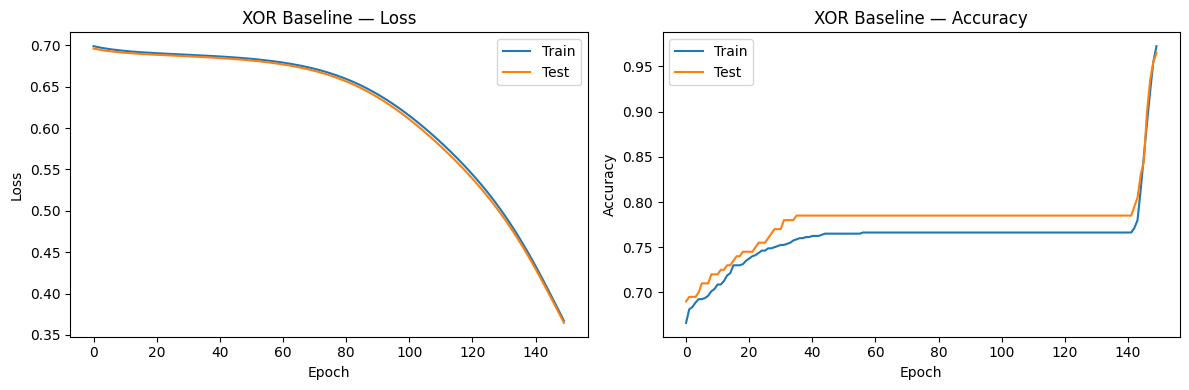

XOR Baseline  Train loss: 0.3671  Test loss: 0.3645  Train acc: 0.9725  Test acc: 0.9650


In [33]:
np.random.seed(42)
N = 1000
X, y = make_xor_data(N)
X_tr, y_tr, X_te, y_te = split(X, y)

model_xor = ANN(n_hidden=2, task='xor', lr=0.5)
hist_xor = train(model_xor, X_tr, y_tr, X_te, y_te, epochs=150)
plot_hist(hist_xor, 'XOR Baseline')
report(hist_xor, "XOR Baseline")

### Cosine : Baseline run

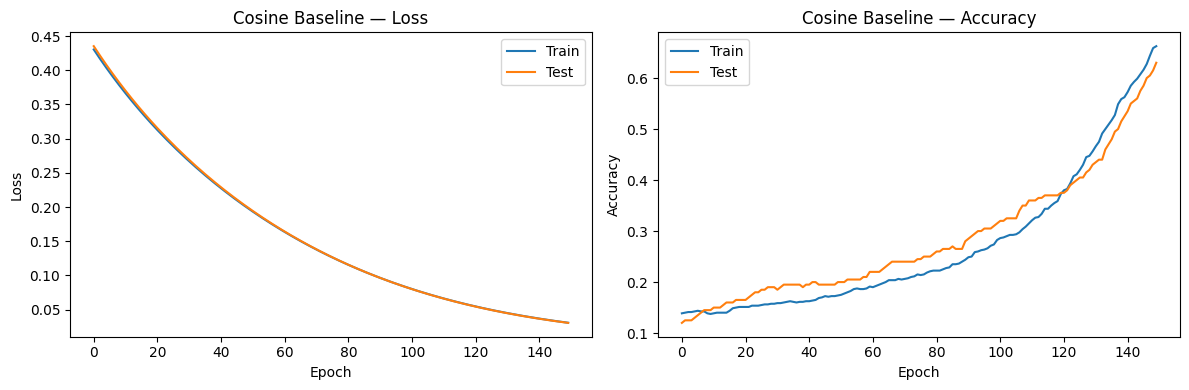

Cosine Baseline  Train loss: 0.0308  Test loss: 0.0306  Train acc: 0.6625  Test acc: 0.6300


In [34]:
np.random.seed(42)
X, y = make_cosine_data(N)
X_tr, y_tr, X_te, y_te = split(X, y)

model_cos = ANN(n_hidden=4, task='cosine', lr=0.01)
hist_cos = train(model_cos, X_tr, y_tr, X_te, y_te, epochs=150)
plot_hist(hist_cos, 'Cosine Baseline')
report(hist_cos, "Cosine Baseline")

### Deterministic GD : Varying *n*

In [39]:
for task, make_data, cfg in [
    ('xor',    make_xor_data,    dict(n_hidden=2, lr=0.5,  epochs=150)),
    ('cosine', make_cosine_data, dict(n_hidden=4, lr=0.01, epochs=150)),
]:
    print(f"\n=== {task.upper()} — Varying n (full-batch GD) ===")
    for n in [200, 500, 2000]:
        np.random.seed(187)
        X, y = make_data(n)
        X_tr, y_tr, X_te, y_te = split(X, y)
        m = ANN(n_hidden=cfg['n_hidden'], task=task, lr=cfg['lr'])
        h = train(m, X_tr, y_tr, X_te, y_te, epochs=cfg['epochs'])
        report(h, f"  n={n}")


=== XOR — Varying n (full-batch GD) ===
  n=200  Train loss: 0.6383  Test loss: 0.6679  Train acc: 0.6125  Test acc: 0.5000
  n=500  Train loss: 0.4290  Test loss: 0.4147  Train acc: 0.7650  Test acc: 0.7500
  n=2000  Train loss: 0.1899  Test loss: 0.1932  Train acc: 1.0000  Test acc: 1.0000

=== COSINE — Varying n (full-batch GD) ===
  n=200  Train loss: 0.0361  Test loss: 0.0325  Train acc: 0.5563  Test acc: 0.7000
  n=500  Train loss: 0.0078  Test loss: 0.0087  Train acc: 1.0000  Test acc: 0.9900
  n=2000  Train loss: 0.0170  Test loss: 0.0159  Train acc: 0.9300  Test acc: 0.9375


### Stochastic GD : Varying *m*

In [40]:
N_FIXED = 1000

for task, make_data, cfg in [
    ('xor',    make_xor_data,    dict(n_hidden=2, lr=0.5,  epochs=150)),
    ('cosine', make_cosine_data, dict(n_hidden=4, lr=0.01, epochs=150)),
]:
    print(f"\n=== {task.upper()} — Varying batch size m (n={N_FIXED}) ===")
    np.random.seed(187)
    X, y = make_data(N_FIXED)
    X_tr, y_tr, X_te, y_te = split(X, y)
    for m in [1, 32, 256]:
        model = ANN(n_hidden=cfg['n_hidden'], task=task, lr=cfg['lr'])
        h = train(model, X_tr, y_tr, X_te, y_te,
                  epochs=cfg['epochs'], batch_size=m)
        report(h, f"  batch={m}")


=== XOR — Varying batch size m (n=1000) ===
  batch=1  Train loss: 0.0001  Test loss: 0.0001  Train acc: 1.0000  Test acc: 1.0000
  batch=32  Train loss: 0.0017  Test loss: 0.0018  Train acc: 1.0000  Test acc: 1.0000
  batch=256  Train loss: 0.0156  Test loss: 0.0152  Train acc: 1.0000  Test acc: 1.0000

=== COSINE — Varying batch size m (n=1000) ===
  batch=1  Train loss: 0.0016  Test loss: 0.0015  Train acc: 1.0000  Test acc: 1.0000
  batch=32  Train loss: 0.0029  Test loss: 0.0034  Train acc: 1.0000  Test acc: 1.0000
  batch=256  Train loss: 0.0034  Test loss: 0.0037  Train acc: 0.9988  Test acc: 1.0000
